# Schwarzschild Black-Hole Raytracer

Final renders for Phase 6: a pure-lensing shot (grid-textured sky + shadow, no disk), the full scene with a lensed accretion disk, a quantitative deflection-angle validation curve (including the photon-sphere divergence), and an orbiting-camera flythrough. See `Schwarzschild_Raytracer_Plan.md` for the physics/design and `Geodesic Validation.ipynb` for the geodesic-integrator validation this all rests on. All figures/animations saved to `media/`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import metric
import geodesics
import camera
import scene
import raytrace

MEDIA = "media"
os.makedirs(MEDIA, exist_ok=True)

M = metric.M_DEFAULT
b_crit = metric.b_critical(M)
print(f"M={M}, r_horizon={metric.r_horizon(M)}, r_photon_sphere={metric.r_photon_sphere(M)}, b_crit={b_crit:.4f}")

M=1.0, r_horizon=2.0, r_photon_sphere=3.0, b_crit=5.1962


## 1. Pure lensing: grid-textured sky + shadow (no disk)

A camera looking straight at the black hole should show an Einstein-ring-like distortion of the checkerboard sky wrapping around a shadow whose angular radius matches the analytic prediction `sin(theta_shadow) = b_crit / r_cam` (for a static observer, ignoring the small aberration correction at this distance).

analytic shadow angular radius = 18.814 deg
measured shadow angular radius = 18.809 deg


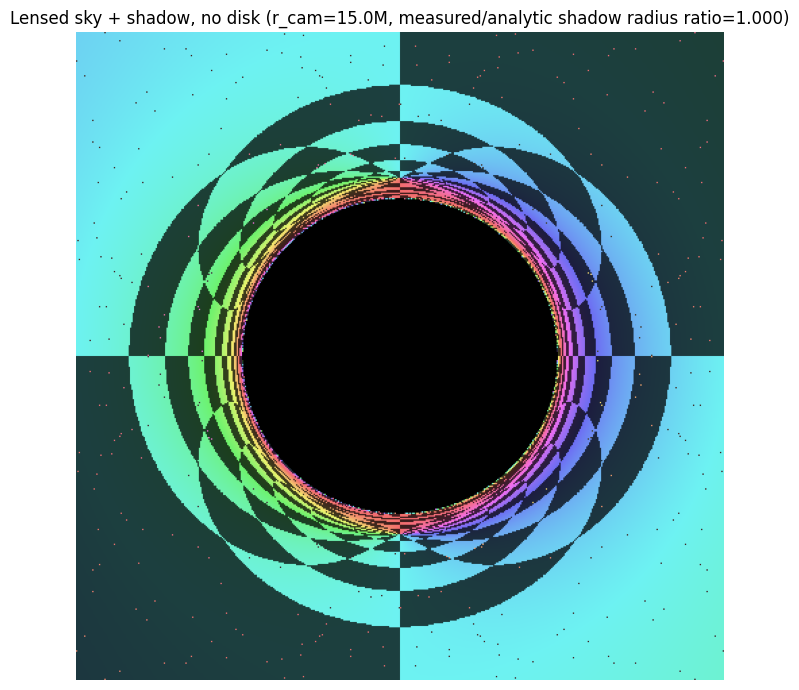

In [2]:
r_cam_A = 15.0 * M
fov_A = 70.0
res_A = (480, 480)

img_A = raytrace.render_fast(res_A, r_cam=r_cam_A, theta_cam=np.pi / 2, disk=False, fov_deg=fov_A, h=5e-3)

# Analytic shadow angular radius (angle from the camera's forward/look direction)
psi_shadow = np.arcsin(b_crit * np.sqrt(metric.f(r_cam_A, M)) / r_cam_A)

# Measured shadow angular radius: scan the central row for the black/sky boundary
central_row = img_A[res_A[1] // 2]
is_black = central_row.max(axis=-1) < 0.02
half_w = np.tan(np.radians(fov_A) / 2)
u_coords = np.linspace(-half_w, half_w, res_A[0])
black_us = np.abs(u_coords[is_black])
psi_measured = np.arctan(black_us.max()) if black_us.size else np.nan

print(f"analytic shadow angular radius = {np.degrees(psi_shadow):.3f} deg")
print(f"measured shadow angular radius = {np.degrees(psi_measured):.3f} deg")

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img_A)
ax.axis("off")
ax.set_title(f"Lensed sky + shadow, no disk (r_cam={r_cam_A}M, measured/analytic shadow radius ratio={psi_measured/psi_shadow:.3f})")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "render_lensing_only.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Full scene: lensed accretion disk

A camera looking down at the disk from a shallow angle (`theta_cam=80deg` from the pole, i.e. 10deg above the disk plane) should show the disk's far side lensed into an arc above the shadow, in addition to its near side below -- the classic "warped ring" look.

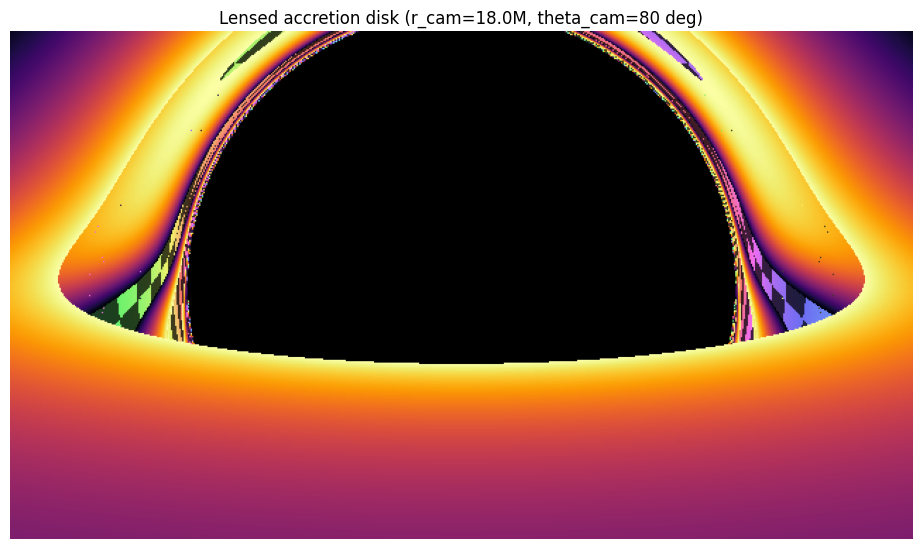

In [3]:
r_cam_B = 18.0 * M
theta_cam_B = np.radians(80)
fov_B = 50.0
res_B = (640, 360)

img_B = raytrace.render_fast(res_B, r_cam=r_cam_B, theta_cam=theta_cam_B, disk=True, fov_deg=fov_B, h=5e-3)

fig, ax = plt.subplots(figsize=(10, 5.6))
ax.imshow(img_B)
ax.axis("off")
ax.set_title(f"Lensed accretion disk (r_cam={r_cam_B}M, theta_cam={np.degrees(theta_cam_B):.0f} deg)")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "render_with_disk.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Deflection angle across the full range, including the photon-sphere divergence

`Geodesic Validation.ipynb` already checked the weak-field limit (`b >> b_crit`) against `4M/b`. This complements it with the full curve down to `b` just above `b_crit`, where the deflection angle diverges (photons whirl arbitrarily many times near the photon sphere the closer `b` gets to critical).

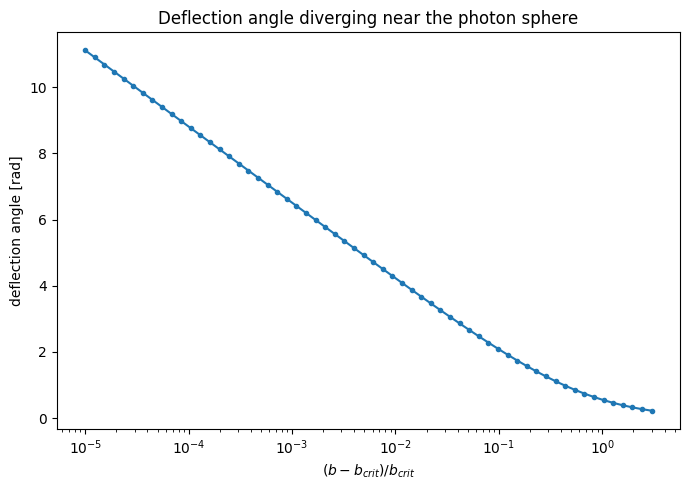

In [4]:
eps = np.geomspace(1e-5, 3.0, 60)  # (b - b_crit) / b_crit
b_values_full = b_crit * (1.0 + eps)
deflection_full = np.array([geodesics.deflection_angle(b, M, phi_max=300 * np.pi) for b in b_values_full])

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(eps, deflection_full, "o-", ms=3)
ax.set_xlabel(r"$(b - b_{crit}) / b_{crit}$")
ax.set_ylabel("deflection angle [rad]")
ax.set_title("Deflection angle diverging near the photon sphere")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "deflection_full_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Stretch: orbiting-camera flythrough

Rotate the camera's `phi_cam` through a full orbit at fixed `r_cam`/`theta_cam`, re-rendering each frame with `render_fast`, to show the lensed disk and photon ring from all sides.

In [5]:
import matplotlib.animation as animation

n_frames = 20
res_anim = (240, 135)
r_cam_anim = 18.0 * M
theta_cam_anim = np.radians(80)

frames = []
for i, phi_cam in enumerate(np.linspace(0, 2 * np.pi, n_frames, endpoint=False)):
    frame = raytrace.render_fast(res_anim, r_cam=r_cam_anim, theta_cam=theta_cam_anim, phi_cam=phi_cam,
                                  disk=True, fov_deg=50, h=5e-3)
    frames.append(frame)
    print(f"frame {i+1}/{n_frames} done", end="\r")

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(frames[0])
ax.axis("off")
ax.set_title("Orbiting camera flythrough")


def update(i):
    im.set_data(frames[i])
    return [im]


ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=150, blit=True)
ani.save(os.path.join(MEDIA, "orbit_flythrough.gif"), writer="pillow", fps=8)
plt.close(fig)
print("saved orbit_flythrough.gif")

saved orbit_flythrough.gif
